<a href="https://colab.research.google.com/github/yonathanalulam/Music-Recommendation-System/blob/main/songPred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install kaggle -q


In [32]:
import os
import json


import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import wordcloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [12]:
kaggle_config = json.load(open('/content/kaggle.json'))
os.environ['KAGGLE_USERNAME'] = kaggle_config['username']
os.environ['KAGGLE_KEY'] = kaggle_config['key']

In [14]:
!kaggle datasets download notshrirang/spotify-million-song-dataset

Dataset URL: https://www.kaggle.com/datasets/notshrirang/spotify-million-song-dataset
License(s): CC0-1.0
  0% 0.00/20.7M [00:00<?, ?B/s]
100% 20.7M/20.7M [00:00<00:00, 1.24GB/s]


In [15]:
!ls

kaggle.json  sample_data  spotify-million-song-dataset.zip


In [16]:
with zipfile.ZipFile('spotify-million-song-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [17]:
df=pd.read_csv("/content/spotify_millsongdata.csv")

In [18]:
df.shape

(57650, 4)

In [19]:
df.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   artist  57650 non-null  object
 1   song    57650 non-null  object
 2   link    57650 non-null  object
 3   text    57650 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [21]:
df.isnull().sum()

,0
artist,0
song,0
link,0
text,0


In [22]:
df.isnull().sum()

,0
artist,0
song,0
link,0
text,0


In [23]:
top_artists = df['artist'].value_counts().head(10)
print("\nTop 10 Artists:")
print(top_artists)



Top 10 Artists:
artist
Donna Summer        191
Gordon Lightfoot    189
Bob Dylan           188
George Strait       188
Loretta Lynn        187
Alabama             187
Cher                187
Reba Mcentire       187
Chaka Khan          186
Dean Martin         186
Name: count, dtype: int64


In [24]:
df = df.sample(10000)

df = df.drop('link', axis=1).reset_index(drop=True)

In [25]:

df.head()

,artist,song,text
0,Katy Perry,Hackensack,I used to know you when we were young \r\nYou...
1,Jimi Hendrix,In From The Storm,"Well I, \r\nJust came back today \r\nI just ..."
2,David Allan Coe,Whips And Things,We're gona do this song for useless \r\nOhhhh...
3,Mariah Carey,Reflections,Reflections of your love \r\nHave come to wit...
4,Taylor Swift,Ours,"Elevator buttons and morning air, \r\nStrange..."


In [26]:

df.shape

(10000, 3)

In [36]:
from wordcloud import WordCloud
all_lyrics = " ".join(df['text'].dropna())
wc = WordCloud(width=800, height=400, background_color="white").generate(all_lyrics)

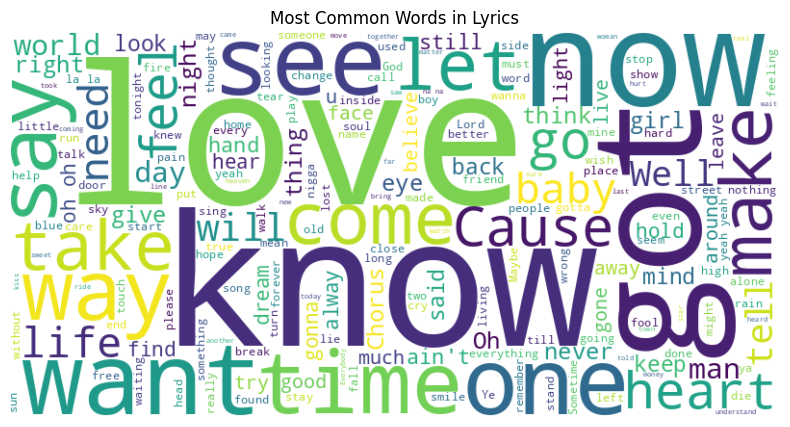

In [38]:
plt.figure(figsize=(10, 5))
plt.imshow(wc.to_array(), interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Lyrics")
plt.show()

In [39]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [40]:
stop_words = set(stopwords.words('english'))

In [41]:
df.head()

,artist,song,text
0,Katy Perry,Hackensack,I used to know you when we were young \r\nYou...
1,Jimi Hendrix,In From The Storm,"Well I, \r\nJust came back today \r\nI just ..."
2,David Allan Coe,Whips And Things,We're gona do this song for useless \r\nOhhhh...
3,Mariah Carey,Reflections,Reflections of your love \r\nHave come to wit...
4,Taylor Swift,Ours,"Elevator buttons and morning air, \r\nStrange..."


In [43]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

In [44]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [45]:
def recommend_songs(song_name, cosine_sim=cosine_sim, df=df, top_n=5):
    # Find the index of the song
    idx = df[df['song'].str.lower() == song_name.lower()].index
    if len(idx) == 0:
        return "Song not found in the dataset!"   # can be reworked to compare for songs not present in the dataset
    idx = idx[0]

    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    # Get song indices
    song_indices = [i[0] for i in sim_scores]

    # Return top n similar songs
    return df[['artist', 'song']].iloc[song_indices]

In [57]:
print(df["song"][3])   #will fetch song at index [i] from the random sample selected
#using Song[3] in this case

Reflections


In [59]:
#recommendation example for the song

print("\nRecommendations for the song 'Reflections':")
recommendations = recommend_songs("Reflections") # df["song"][3]
print(recommendations)


Recommendations for the song 'Reflections':
             artist                  song
2055   Fall Out Boy          I Don't Care
287   Nat King Cole         I Should Care
5967    Tom T. Hall                I Care
9009    Ray Charles    I'm A Fool To Care
4547     Cinderella  If You Don't Like It
